# Robustness of beta/eta estimation methods: global and regional maps

4x2 panels: `REF` (top-left) against the other six carbonate-sensitivity estimation methods (`MON`, `MEAN`, `CONST`, `CESM`, `SODA-mon`, `SODA-clim` — same labels/exps as in `curves_different_beta_eta.ipynb`). Each panel shows $\beta$ or $\eta$ as archived in that method's ROMS forcing file (`roms/exp{N}/INPUT/roms_surf_flux_*.nc`), at the time step nearest a chosen date.

Two kinds of figures:
- **Global**: one 4x2 figure over the full model domain.
- **Regional**: one 4x2 figure per region (same 4 regions as `beta_eta_second_order.ipynb`: Japan, Vancouver Island, Baja California, Ecuador), all 7 panels zoomed to that region.

In [1]:
import xarray as xr

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from roms_tools import Grid
from plot import _finish_panel, ZOOM_COORDS

## Configuration

In [3]:
METHODS = {
    "REF":       {"exp": 0},
    "MON":       {"exp": 1},
    "MEAN":      {"exp": 2},
    "CONST":     {"exp": 6},
    "CESM":      {"exp": 3},
    "SODA-mon":  {"exp": 8},
    "SODA-clim": {"exp": 9},
}

# (row, col, method_key); method_key=None -> empty panel
PANEL_ORDER = [
    (0, 0, "REF"),
    (0, 1, None),
    (1, 0, "MON"),
    (1, 1, "MEAN"),
    (2, 0, "CONST"),
    (2, 1, "CESM"),
    (3, 0, "SODA-mon"),
    (3, 1, "SODA-clim"),
]

variables = {
    "beta": {"key": "ddic_dco2", "symbol": r"\beta", "cmap": "inferno"},
    "eta":  {"key": "ddic_dalk", "symbol": r"\eta",  "cmap": "viridis"},
}

locations = ["JP", "VI", "BC", "EC"]

# Centralized in plot.py (ZOOM_COORDS) so it only needs editing in one place.
zoom_coords = {loc: ZOOM_COORDS[loc] for loc in locations}

YEAR = 2000
TARGET_DATE = "2000-01-01"

## Load grid

In [4]:
grid_file = "roms_marbl_dic/expCTRL/pacmed12_grd.nc"
grid = Grid.from_file(grid_file, theta_s=6.0, theta_b=6.0, hc=250.0, N=100)

lon = grid.ds["lon_rho"]
lat = grid.ds["lat_rho"]
mask = grid.ds["mask_rho"].astype(bool)

2026-09-21 04:49:32 - INFO - === Preparing the vertical coordinate system using N = 100, theta_s = 6.0, theta_b = 6.0, hc = 250.0 ===
2026-09-21 04:49:32 - INFO - Total time: 0.003 seconds
2026-09-21 04:49:32 - INFO - ================================================================================================


## Load data

Each method's forcing file fills land with 0 (see `sensitivities.py`), so `mask` is applied when plotting to hide land instead of showing spurious zeros.

In [5]:
def load_method(method_key, year=YEAR):
    exp = METHODS[method_key]["exp"]
    return xr.open_dataset(f"roms/exp{exp}/INPUT/roms_surf_flux_{year}.nc")

datasets = {method_key: load_method(method_key) for method_key in METHODS}

Each file uses either an `itime` or a `time` dimension (depending on the method's construction), and different buffering/repetition schemes along it. Rather than hardcoding indices per method, look up the index nearest `TARGET_DATE` using the `ddic_dco2_time` variable (days since 1995-01-01) that every file carries.

In [6]:
REF_DATE = pd.Timestamp("1995-01-01")

def nearest_time_idx(ds, target_date=TARGET_DATE):
    target_days = (pd.Timestamp(target_date) - REF_DATE).total_seconds() / 86400
    time_dim = "itime" if "itime" in ds.dims else "time"
    idx = int(np.argmin(np.abs(ds["ddic_dco2_time"].values - target_days)))
    return idx, time_dim

## Plotting

Global projection/extent follow `carbonate_sensitivities.ipynb`: `PlateCarree(central_longitude=180)`, restricted to `lon in [-93, 112]` (latitude left at its auto-computed extent). All panels within a given figure share one colorbar, scaled to that figure's combined data range.

In [19]:
def _new_panel_axes(fig, axs, row, col, projection):
    axs[row, col].remove()
    ax = fig.add_subplot(4, 2, 2 * row + col + 1, projection=projection)
    axs[row, col] = ax
    return ax


def _empty_panel(fig, axs, row, col):
    axs[row, col].remove()
    axs[row, col] = fig.add_subplot(4, 2, 2 * row + col + 1)
    axs[row, col].set_visible(False)


def _shared_vlims(fields):
    vmin = min(float(f.min(skipna=True)) for f in fields.values())
    vmax = max(float(f.max(skipna=True)) for f in fields.values())
    return vmin, vmax


def _symmetric_vlims(fields):
    """Symmetric limits about 0, for difference (REF - method) panels."""
    amax = max(max(abs(float(f.min(skipna=True))), abs(float(f.max(skipna=True))))
               for f in fields.values())
    return -amax, amax


def _resolve_vlims(fields, vmin, vmax, symmetric=False):
    """Use the shared data range for whichever of vmin/vmax is left as None."""
    data_vmin, data_vmax = _symmetric_vlims(fields) if symmetric else _shared_vlims(fields)
    return (data_vmin if vmin is None else vmin,
            data_vmax if vmax is None else vmax)


def _panel_title(symbol, method_key, panel_labels, panel_idx, diff_ref=False):
    """(a) beta_REF style title; panel_idx counts only non-empty panels."""
    if diff_ref:
        base = rf"${symbol}_\mathtt{{{method_key}}} - {symbol}_\mathtt{{REF}}$"
    else:
        base = rf"${symbol}_\mathtt{{{method_key}}}$"
    if panel_labels and panel_idx < len(panel_labels):
        return f"({panel_labels[panel_idx]}) {base}"
    return base


def _add_minmax_text(ax, field, nr_digits, fontsize=11):
    vmin_data = float(field.min(skipna=True))
    vmax_data = float(field.max(skipna=True))
    ax.text(0.6, 0.05, f"Min: {vmin_data:.{nr_digits}f}  Max: {vmax_data:.{nr_digits}f}",
            transform=ax.transAxes, ha="center", va="center", fontsize=fontsize)


def _finish_global_panel(ax, lon_min, lon_max, proj):
    ax.coastlines(resolution="50m", linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)

    # restrict longitude only; keep the auto-computed latitude extent from the plotted data
    lat_min, lat_max = ax.get_extent(crs=proj)[2:]
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5,
                      linestyle="--", x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    gl.rotate_labels = False
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 30))
    gl.ylocator = mticker.FixedLocator(np.arange(-80, 81, 20))
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER


PANEL_LABELS = list("abcdefghijklmnop")


def plot_global_4x2(var_key, target_date=TARGET_DATE, figsize=(11, 14), nr_digits=1,
                    vmin=None, vmax=None, panel_labels=PANEL_LABELS,
                    diff_ref=False, diff_cmap="RdBu_r"):
    """4x2 figure over the full domain: REF (0,0), empty (0,1), other 6 methods.

    Uses the same projection/extent as carbonate_sensitivities.ipynb and one
    colorbar shared across all panels. vmin/vmax set the shared colorbar limits;
    either left as None falls back to that figure's combined data range.
    panel_labels prefixes each non-empty panel title with (a), (b), ...; pass
    None to omit.
    diff_ref=True instead plots (REF - method) for the 6 non-REF methods (the REF
    panel is left blank), on a symmetric-about-0 diff_cmap colorbar.
    """
    var = variables[var_key]
    field_name, symbol, cmap = var["key"], var["symbol"], var["cmap"]

    proj = ccrs.PlateCarree(central_longitude=180)
    lon_min, lon_max = -93, 112

    fields = {}
    for _, _, method_key in PANEL_ORDER:
        if method_key is None:
            continue
        ds = datasets[method_key]
        idx, time_dim = nearest_time_idx(ds, target_date)
        fields[method_key] = ds[field_name].isel({time_dim: idx}).where(mask)

    if diff_ref:
        ref = fields["REF"]
        fields = {k: (v - ref) for k, v in fields.items() if k != "REF"}
        cmap = diff_cmap

    vmin, vmax = _resolve_vlims(fields, vmin, vmax, symmetric=diff_ref)

    fig, axs = plt.subplots(4, 2, figsize=figsize)
    p = None
    panel_idx = 0
    for row, col, method_key in PANEL_ORDER:
        if method_key is None or (diff_ref and method_key == "REF"):
            _empty_panel(fig, axs, row, col)
            continue

        ax = _new_panel_axes(fig, axs, row, col, proj)
        field = fields[method_key]
        p = ax.pcolormesh(lon, lat, field, transform=ccrs.PlateCarree(),
                          cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(_panel_title(symbol, method_key, panel_labels, panel_idx, diff_ref))
        if not diff_ref:
            _add_minmax_text(ax, field, nr_digits)
        _finish_global_panel(ax, lon_min, lon_max, proj)
        panel_idx += 1

    fig.subplots_adjust(hspace=0.4, wspace=0.15, bottom=0.06)
    cbar_ax = fig.add_axes([0.15, 0.0, 0.7, 0.015])
    label = ""
    fig.colorbar(p, cax=cbar_ax, orientation="horizontal", label=label)
    return fig


def plot_regional_4x2(var_key, loc, target_date=TARGET_DATE, figsize=(9, 14), nr_digits=2,
                      vmin=None, vmax=None, panel_labels=PANEL_LABELS,
                      diff_ref=False, diff_cmap="RdBu_r"):
    """4x2 figure zoomed to one region: REF (0,0), empty (0,1), other 6 methods.

    All panels within the figure share one colorbar. vmin/vmax set its limits;
    either left as None falls back to that region's combined data range.
    panel_labels prefixes each non-empty panel title with (a), (b), ...; pass
    None to omit.
    diff_ref=True instead plots (REF - method) for the 6 non-REF methods (the REF
    panel is left blank), on a symmetric-about-0 diff_cmap colorbar.
    """
    var = variables[var_key]
    field_name, symbol, cmap = var["key"], var["symbol"], var["cmap"]

    zc = zoom_coords[loc]
    lon_min, lon_max = zc["lon_min"], zc["lon_max"]
    lat_min, lat_max = zc["lat_min"], zc["lat_max"]
    lon_min_adj = lon_min - 360 if lon_min > 0 else lon_min
    lon_max_adj = lon_max - 360 if lon_max > 0 else lon_max
    region_mask = (
        (lon >= lon_min_adj) & (lon <= lon_max_adj)
        & (lat >= lat_min) & (lat <= lat_max) & mask
    )

    proj = ccrs.LambertConformal(
        central_longitude=(lon_min + lon_max) / 2,
        central_latitude=(lat_min + lat_max) / 2,
    )

    full_fields, zoom_fields = {}, {}
    for _, _, method_key in PANEL_ORDER:
        if method_key is None:
            continue
        ds = datasets[method_key]
        idx, time_dim = nearest_time_idx(ds, target_date)
        field = ds[field_name].isel({time_dim: idx}).where(mask)
        full_fields[method_key] = field
        zoom_fields[method_key] = field.where(region_mask)

    if diff_ref:
        full_ref, zoom_ref = full_fields["REF"], zoom_fields["REF"]
        full_fields = {k: (v - full_ref) for k, v in full_fields.items() if k != "REF"}
        zoom_fields = {k: (v - zoom_ref) for k, v in zoom_fields.items() if k != "REF"}
        cmap = diff_cmap

    vmin, vmax = _resolve_vlims(zoom_fields, vmin, vmax, symmetric=diff_ref)

    fig, axs = plt.subplots(4, 2, figsize=figsize)
    p = None
    panel_idx = 0
    for row, col, method_key in PANEL_ORDER:
        if method_key is None or (diff_ref and method_key == "REF"):
            _empty_panel(fig, axs, row, col)
            continue

        ax = _new_panel_axes(fig, axs, row, col, proj)
        p = ax.pcolormesh(lon, lat, full_fields[method_key], transform=ccrs.PlateCarree(),
                          cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(_panel_title(symbol, method_key, panel_labels, panel_idx, diff_ref))
        #_add_minmax_text(ax, zoom_fields[method_key], nr_digits)
        _finish_panel(ax, lon_min, lon_max, lat_min, lat_max, loc)
        panel_idx += 1

    fig.subplots_adjust(hspace=0.4, wspace=0.15, bottom=0.06)
    cbar_ax = fig.add_axes([0.15, 0.0, 0.7, 0.012])
    label = ""
    fig.colorbar(p, cax=cbar_ax, orientation="horizontal", label=label)
    return fig

## $\beta$

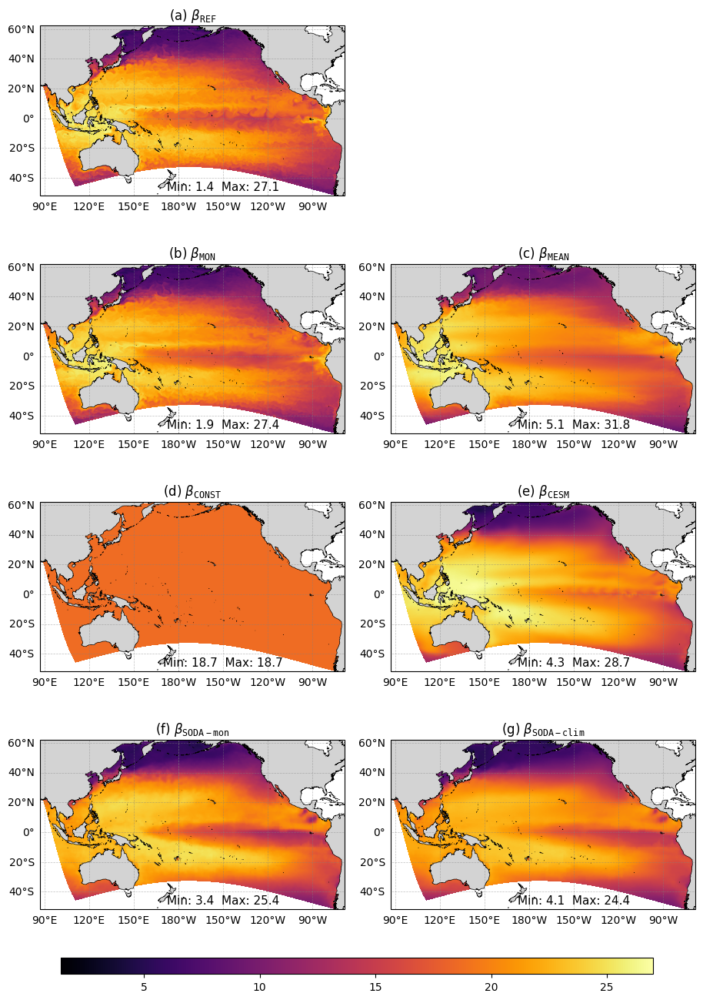

In [67]:
fig = plot_global_4x2("beta", vmin=None, vmax=27)
fig.savefig("figures/robustness_global_beta.png", dpi=300, bbox_inches="tight")

### Regional maps (one figure per region)

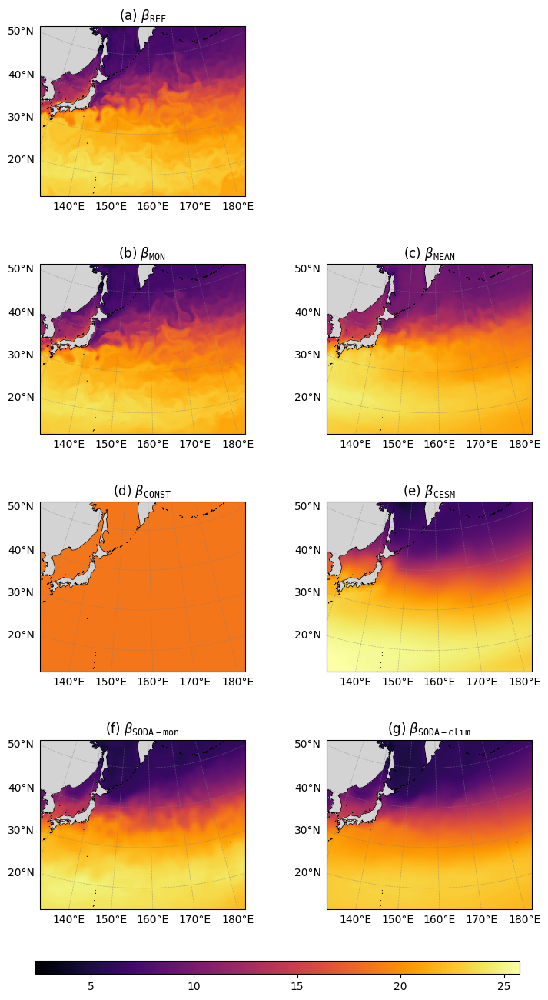

In [68]:
loc = "JP"
fig = plot_regional_4x2("beta", loc, vmin=None, vmax=None)
fig.savefig(f"figures/robustness_regional_beta_{loc}.png", dpi=300, bbox_inches="tight")

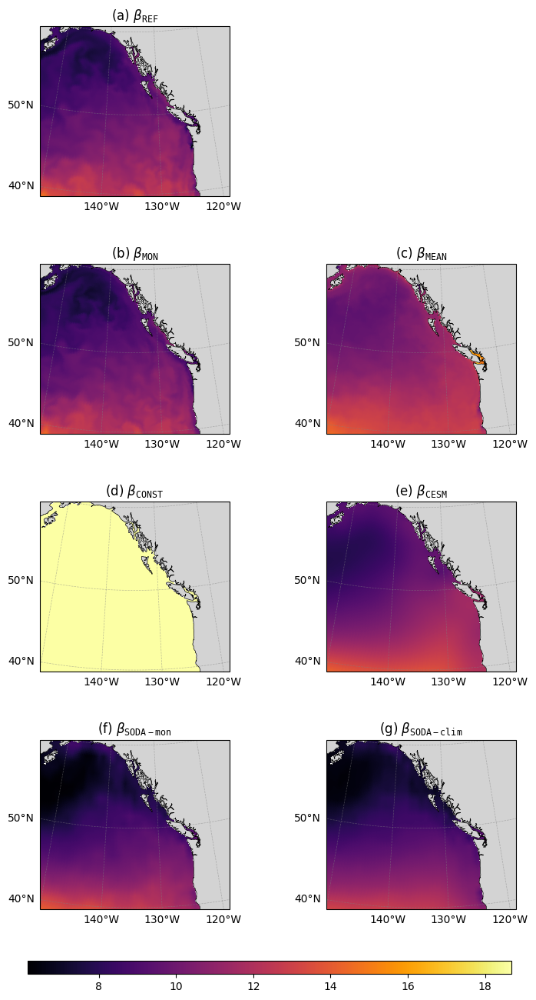

In [69]:
loc = "VI"
fig = plot_regional_4x2("beta", loc, vmin=None, vmax=None)
fig.savefig(f"figures/robustness_regional_beta_{loc}.png", dpi=300, bbox_inches="tight")

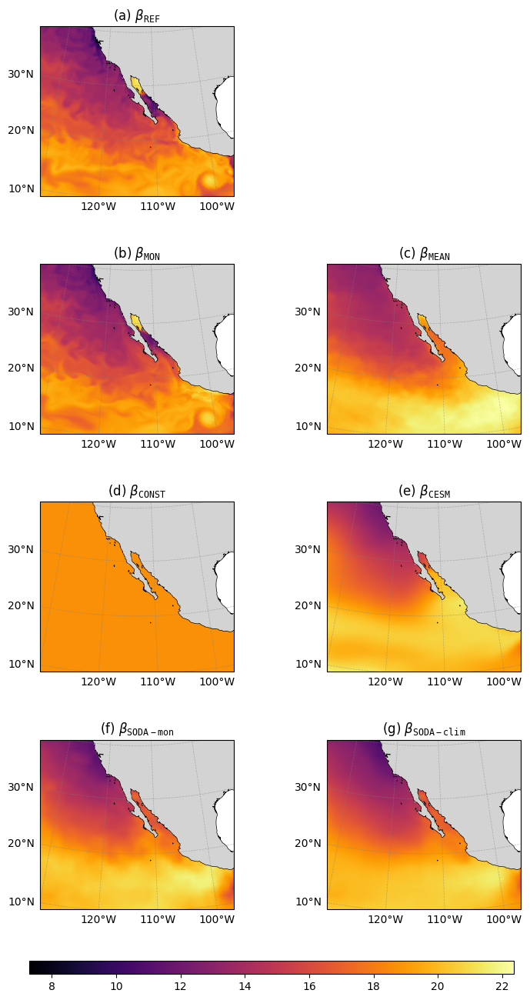

In [70]:
loc = "BC"
fig = plot_regional_4x2("beta", loc, vmin=None, vmax=None)
fig.savefig(f"figures/robustness_regional_beta_{loc}.png", dpi=300, bbox_inches="tight")

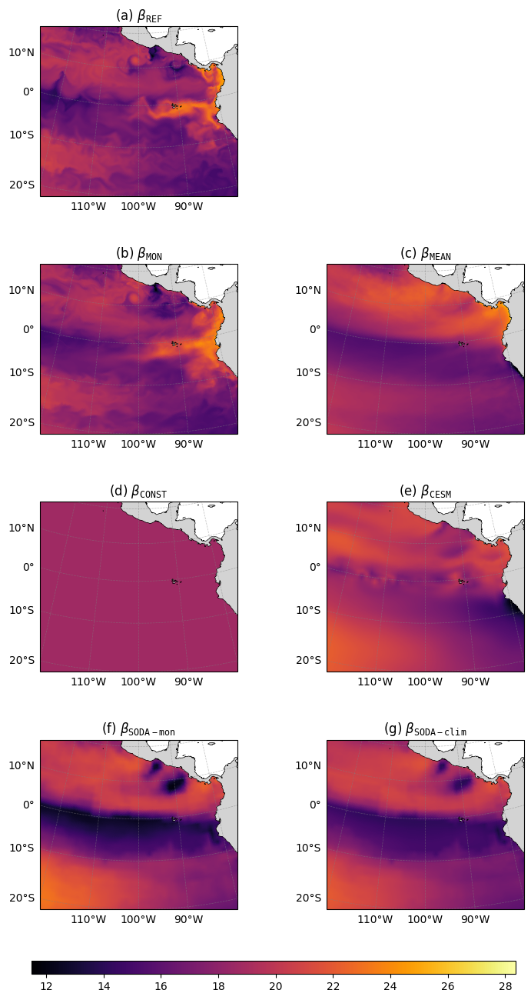

In [71]:
loc = "EC"
fig = plot_regional_4x2("beta", loc, vmin=None, vmax=None)
fig.savefig(f"figures/robustness_regional_beta_{loc}.png", dpi=300, bbox_inches="tight")

## $\eta$

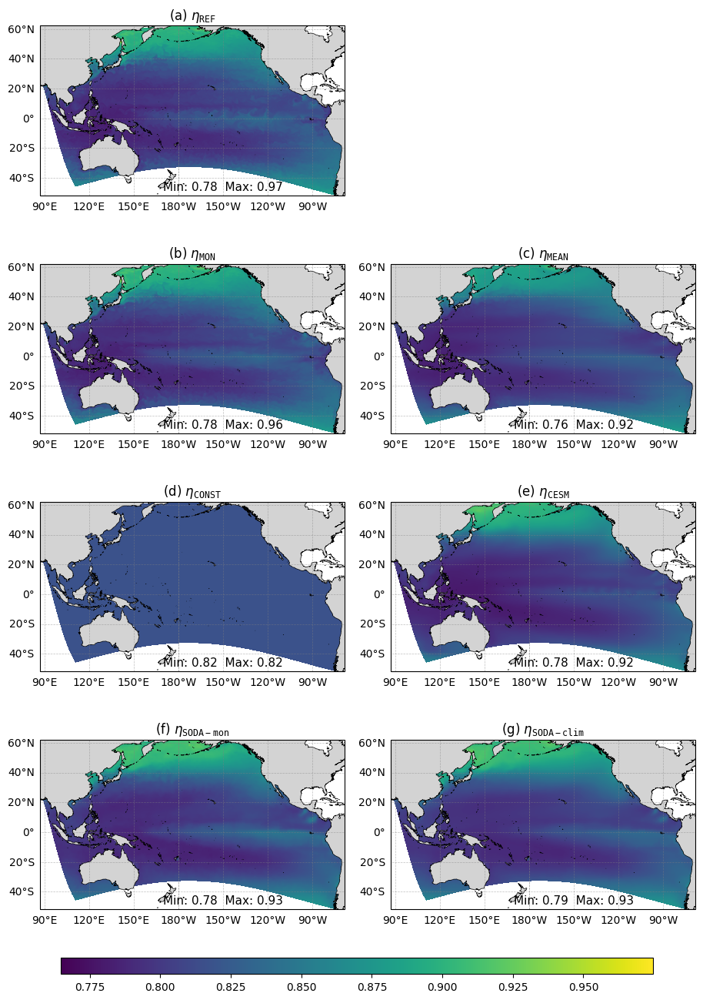

In [72]:
fig = plot_global_4x2("eta", vmin=None, vmax=None, nr_digits=2)
fig.savefig("figures/robustness_global_eta.png", dpi=300, bbox_inches="tight")

### Regional maps

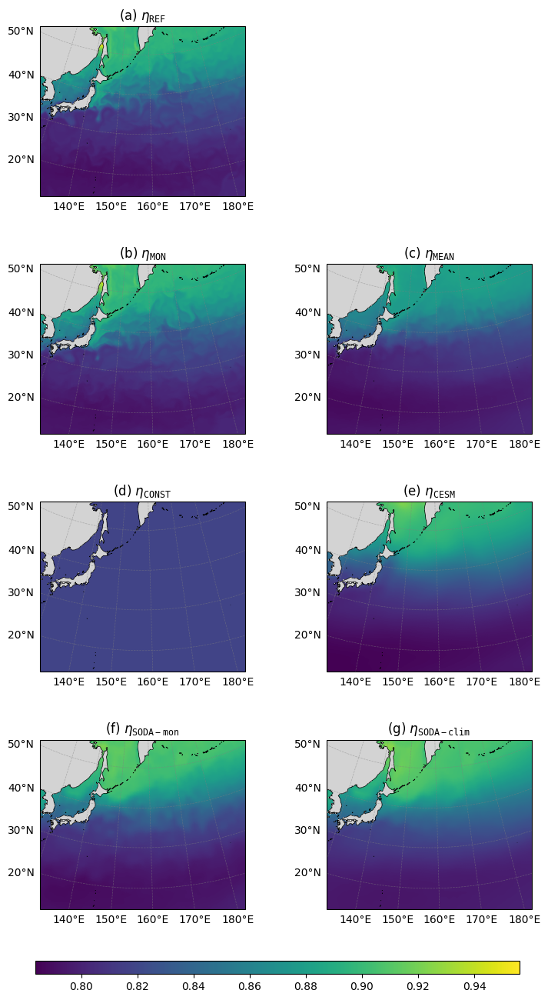

In [8]:
loc = "JP"
fig = plot_regional_4x2("eta", loc, vmin=None, vmax=None)
fig.savefig(f"figures/robustness_regional_eta_{loc}.png", dpi=300, bbox_inches="tight")

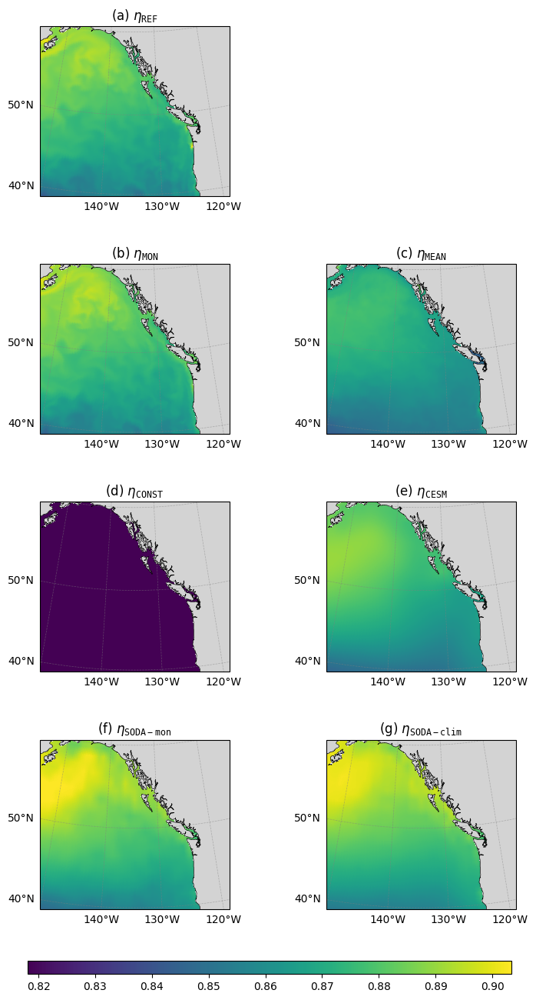

In [9]:
loc = "VI"
fig = plot_regional_4x2("eta", loc, vmin=None, vmax=None)
fig.savefig(f"figures/robustness_regional_eta_{loc}.png", dpi=300, bbox_inches="tight")

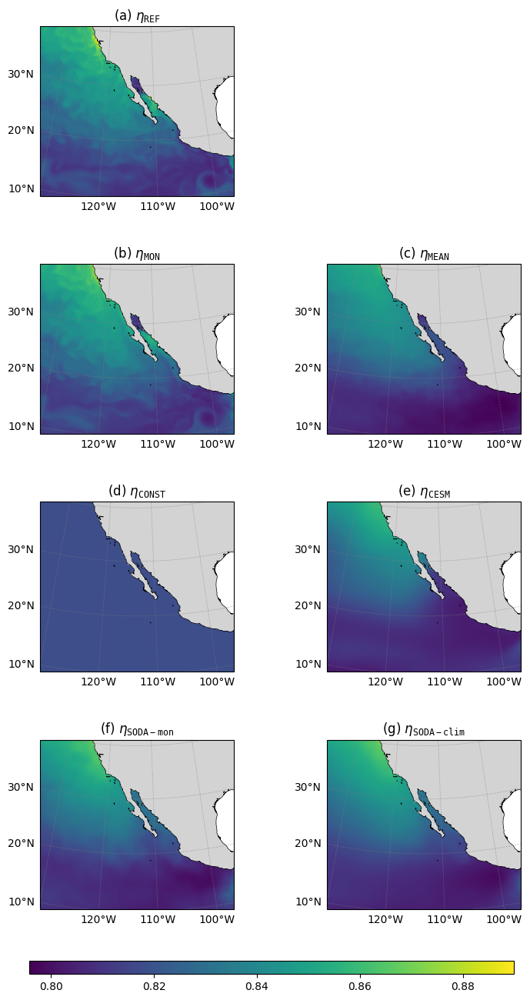

In [10]:
loc = "BC"
fig = plot_regional_4x2("eta", loc, vmin=None, vmax=None)
fig.savefig(f"figures/robustness_regional_eta_{loc}.png", dpi=300, bbox_inches="tight")

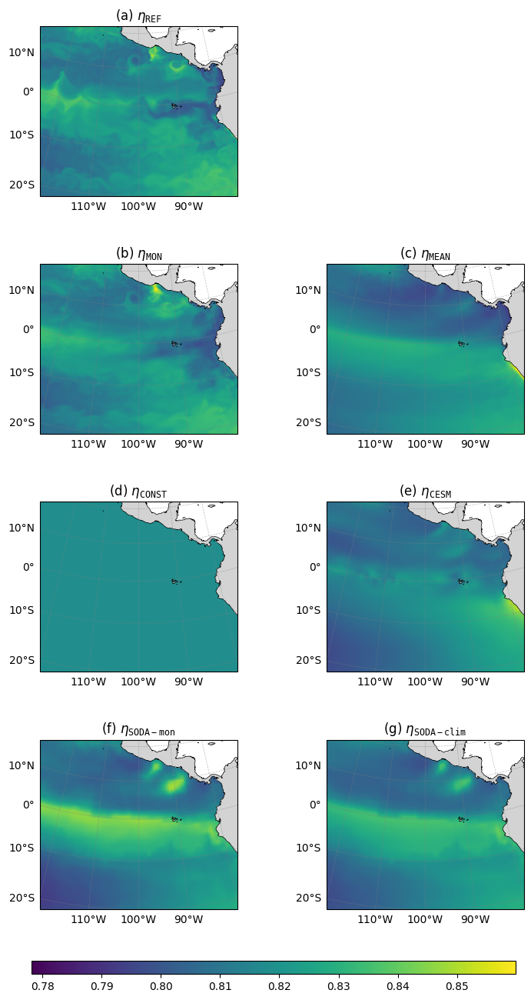

In [11]:
loc = "EC"
fig = plot_regional_4x2("eta", loc, vmin=None, vmax=None)
fig.savefig(f"figures/robustness_regional_eta_{loc}.png", dpi=300, bbox_inches="tight")

## Difference from REF

`diff_ref=True` plots `REF - method` (CDR Tracer − Truth) for the six non-REF methods (REF panel left
blank), on a symmetric diverging colorbar. Set `vmin`/`vmax` to fix the range.

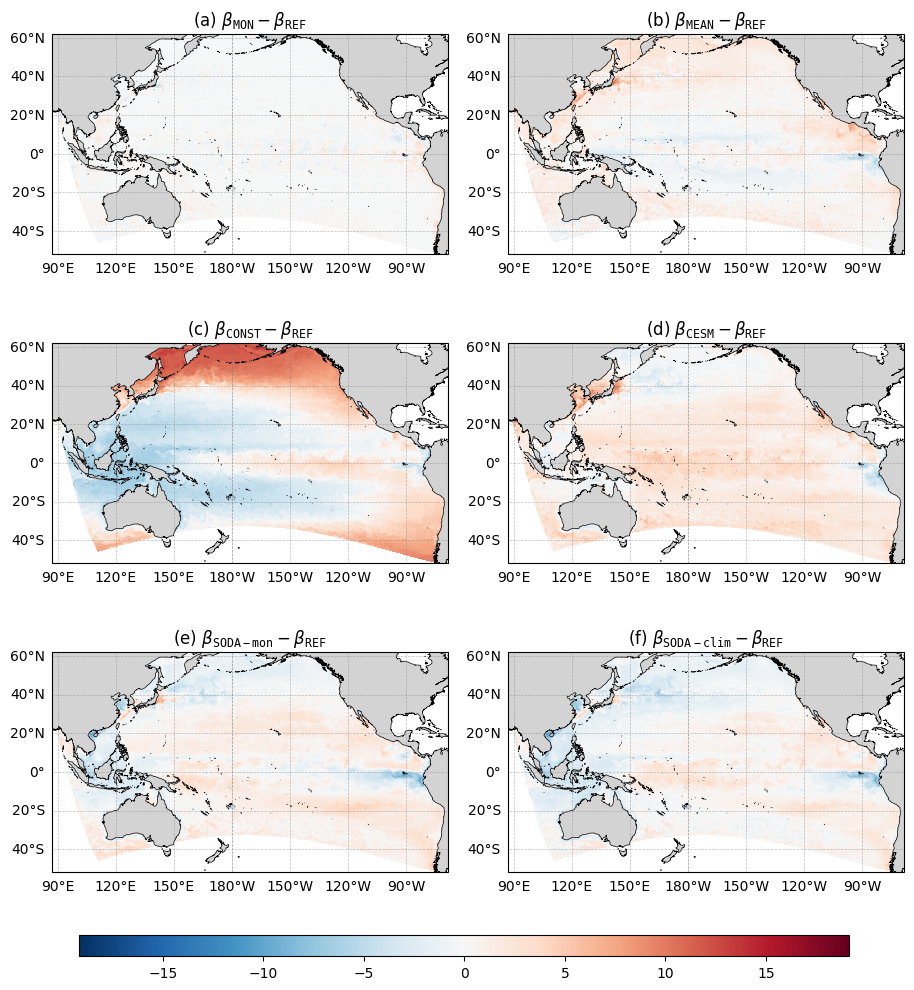

In [20]:
fig = plot_global_4x2("beta", diff_ref=True, vmin=None, vmax=None)
fig.savefig("figures/robustness_global_beta_diff_ref.png", dpi=300, bbox_inches="tight")

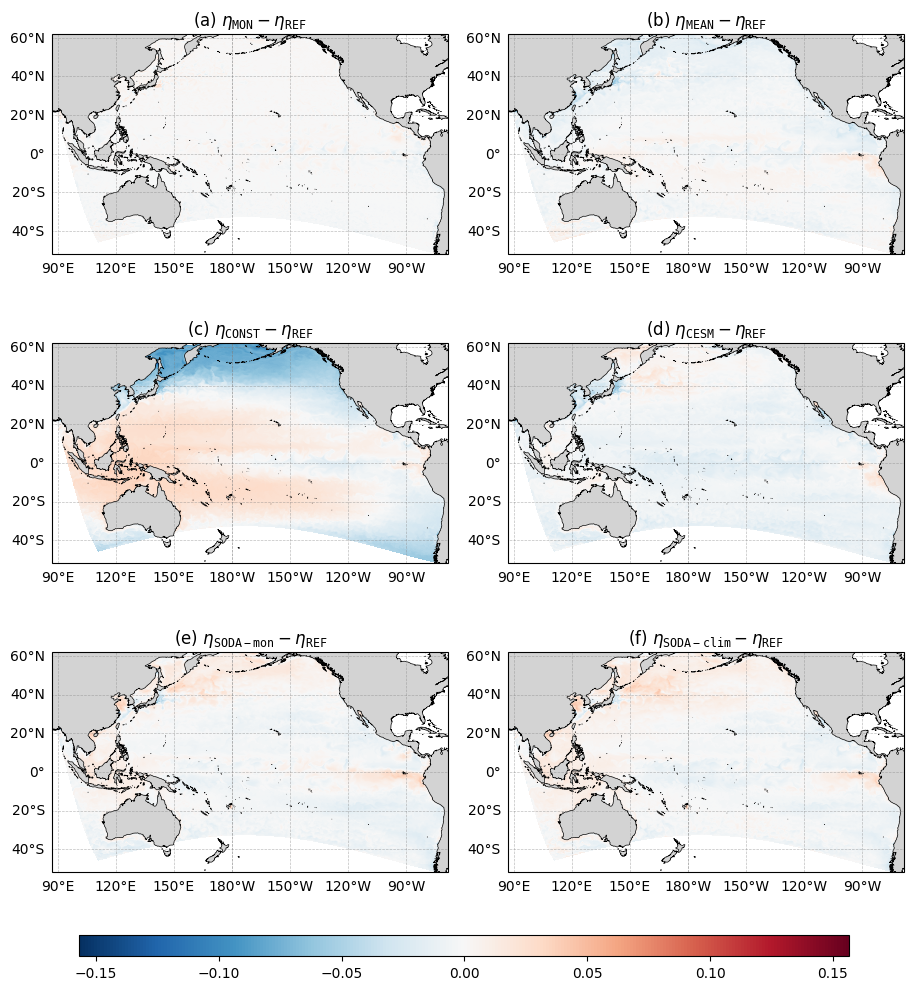

In [21]:
fig = plot_global_4x2("eta", diff_ref=True, vmin=None, vmax=None, nr_digits=2)
fig.savefig("figures/robustness_global_eta_diff_ref.png", dpi=300, bbox_inches="tight")

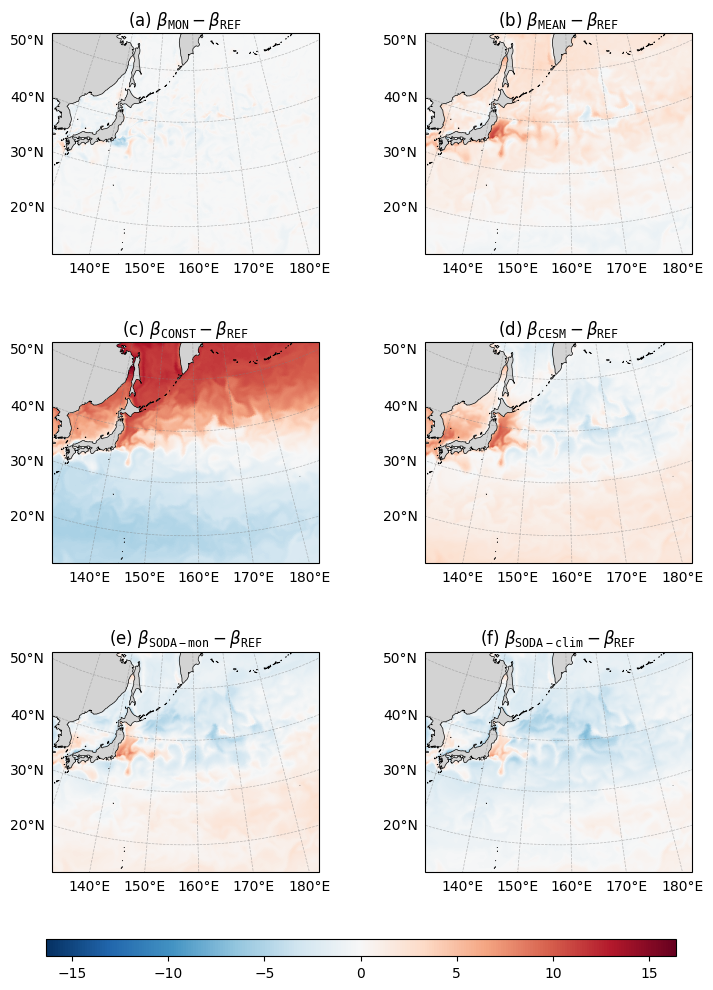

In [73]:
loc = "JP"
fig = plot_regional_4x2("beta", loc, diff_ref=True, vmin=None, vmax=None)
fig.savefig(f"figures/robustness_regional_beta_diff_ref_{loc}.png", dpi=300, bbox_inches="tight")

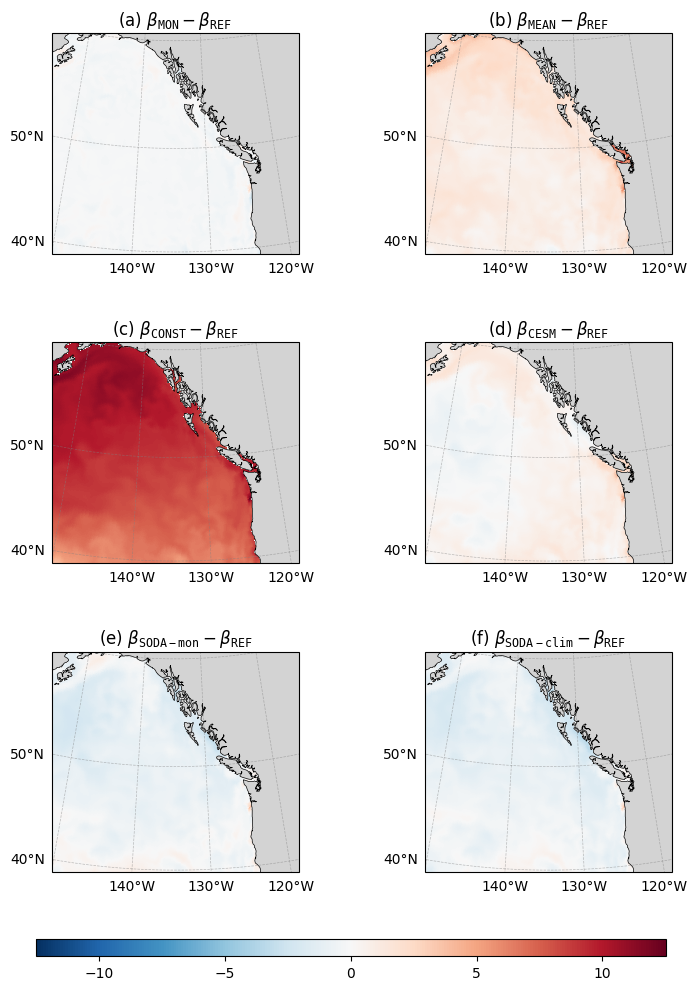

In [74]:
loc = "VI"
fig = plot_regional_4x2("beta", loc, diff_ref=True, vmin=None, vmax=None)
fig.savefig(f"figures/robustness_regional_beta_diff_ref_{loc}.png", dpi=300, bbox_inches="tight")

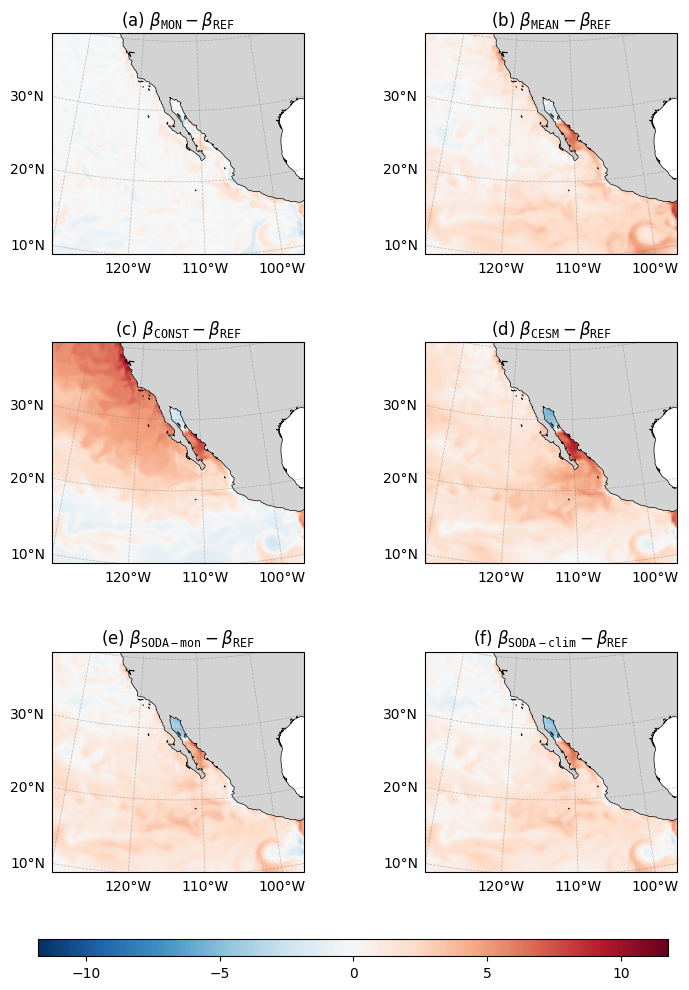

In [75]:
loc = "BC"
fig = plot_regional_4x2("beta", loc, diff_ref=True, vmin=None, vmax=None)
fig.savefig(f"figures/robustness_regional_beta_diff_ref_{loc}.png", dpi=300, bbox_inches="tight")

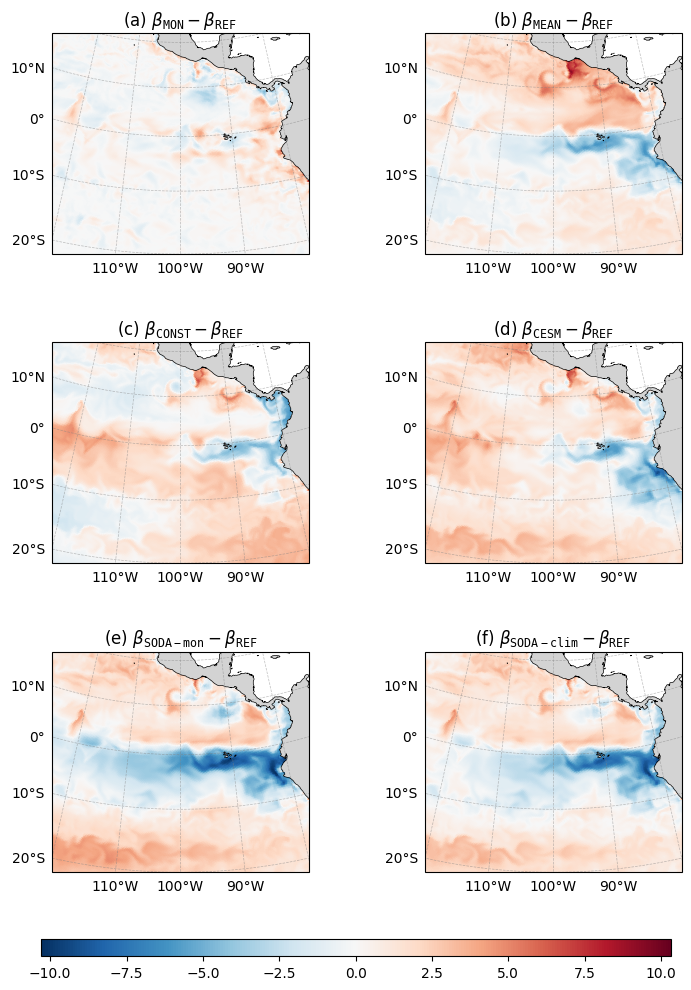

In [76]:
loc = "EC"
fig = plot_regional_4x2("beta", loc, diff_ref=True, vmin=None, vmax=None)
fig.savefig(f"figures/robustness_regional_beta_diff_ref_{loc}.png", dpi=300, bbox_inches="tight")

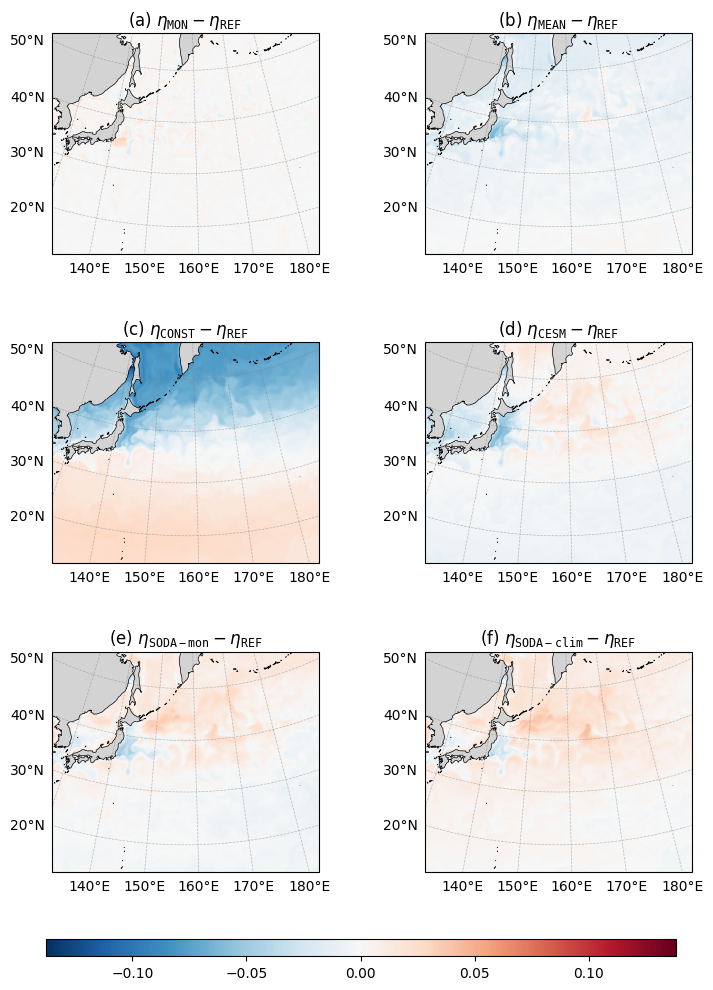

In [22]:
loc = "JP"
fig = plot_regional_4x2("eta", loc, diff_ref=True, vmin=None, vmax=None)
fig.savefig(f"figures/robustness_regional_eta_diff_ref_{loc}.png", dpi=300, bbox_inches="tight")

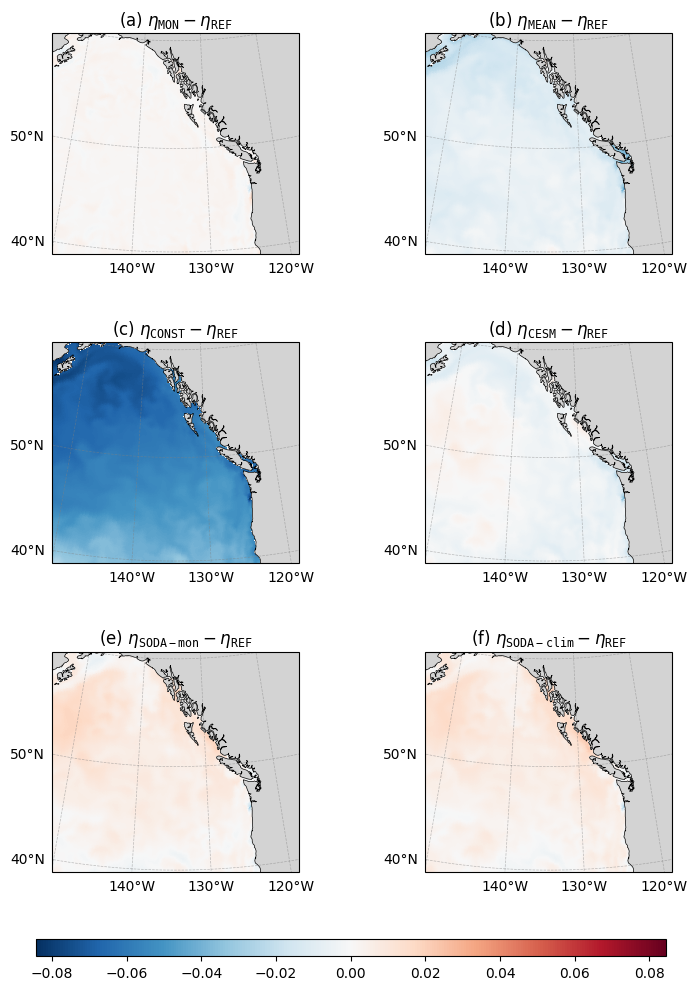

In [23]:
loc = "VI"
fig = plot_regional_4x2("eta", loc, diff_ref=True, vmin=None, vmax=None)
fig.savefig(f"figures/robustness_regional_eta_diff_ref_{loc}.png", dpi=300, bbox_inches="tight")

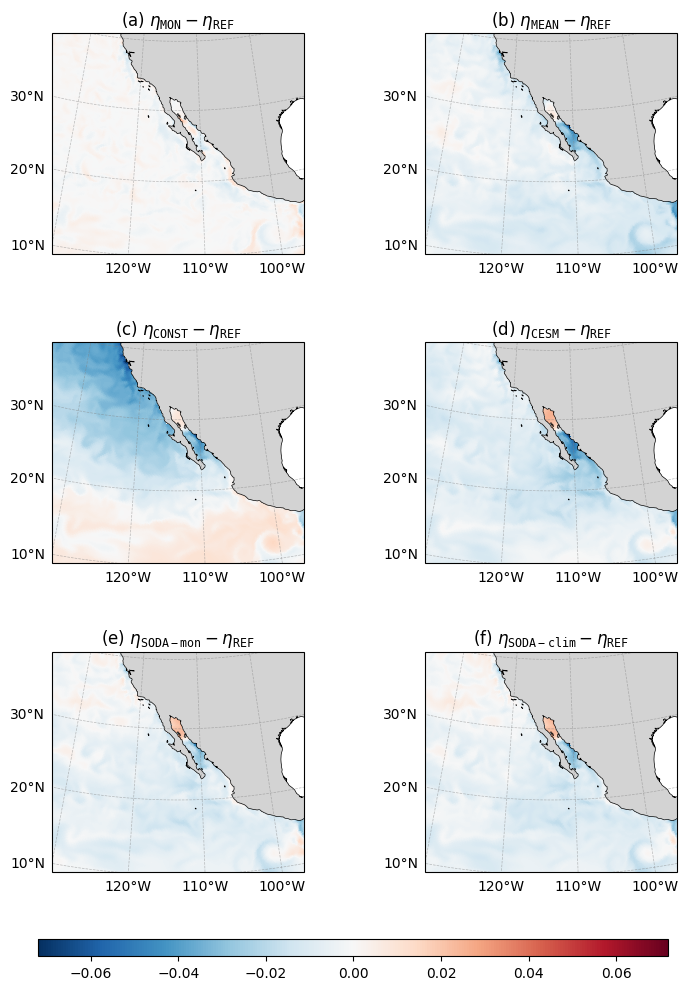

In [24]:
loc = "BC"
fig = plot_regional_4x2("eta", loc, diff_ref=True, vmin=None, vmax=None)
fig.savefig(f"figures/robustness_regional_eta_diff_ref_{loc}.png", dpi=300, bbox_inches="tight")

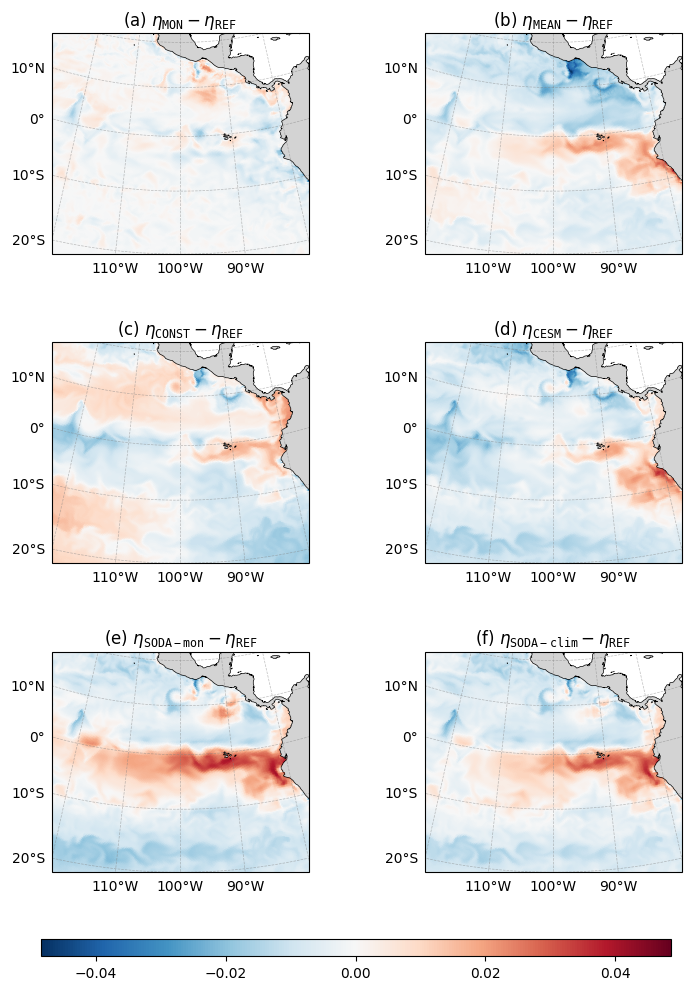

In [25]:
loc = "EC"
fig = plot_regional_4x2("eta", loc, diff_ref=True, vmin=None, vmax=None)
fig.savefig(f"figures/robustness_regional_eta_diff_ref_{loc}.png", dpi=300, bbox_inches="tight")